# 08 - Task 3: Predicted class balance as the dominant leaderboard factor

This notebook documents predicted class balance and turns it
into a designed experiment rather than another guess.

**The observation.** Across all six submissions with a real Kaggle score, the fraction
of rows predicted machine (class 1) ranks the leaderboard result *perfectly* -
Spearman -1.0. Every model over-predicts the machine class relative to train's 62.52%,
and the more it over-predicts, the worse it scores.

**Why this is not the threshold tuning that already failed:** 06/06b/06c tuned
thresholds against out-of-fold CV probabilities and submitted the result; two of three
lost on Kaggle. The class-balance
view says that those searches all moved the linear models' thresholds
*down* (more machine predictions), which is the wrong direction. LightGBM's was the only
one that moved *up*, and it was the only one that helped. 
It was being pulled the wrong way, because it was being fit to the train distribution.

**The risk:** This is a public-leaderboard-directed adjustment, and the brief
warns against over-engineering to the public leaderboard. Two things argue it is still
worth doing: the effect spans ~0.038 Macro F1, far larger than plausible sampling noise
on ~3.5k scored rows, and it is one calibration constant rather than added model
complexity. But the private leaderboard is what is graded, and section 5 records what
would falsify this.

## 0. Setup

In [1]:
# Adds project root to path so `import src...` works from notebooks/.
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import json
import joblib

from src import paths, data, evaluation
from src.paths import FIGURES
FIGURES.mkdir(parents=True, exist_ok=True)

## 1. The evidence

Machine-class share is read back from the actual submission CSVs on disk, not retyped,
so this table cannot drift from what was really uploaded.

In [2]:
# (submission file, label, real public-leaderboard Macro F1)
SCORED = [
    ("logreg_elasticnet_task3_default_threshold.csv", "elasticnet @ 0.500", 0.69576),
    ("logreg_ridge_task3_default_threshold.csv", "ridge @ 0.500", 0.68681),
    ("logreg_elasticnet_task3_tuned_threshold.csv", "elasticnet @ 0.460", 0.67577),
    ("logreg_ridge_task3.csv", "ridge @ 0.475", 0.67105),
    ("final_task3.csv", "lightgbm @ 0.525", 0.66502),
    ("lightgbm_task3_default_threshold.csv", "lightgbm @ 0.500", 0.65738),
]

rows = []
for fname, label, score in SCORED:
    sub = pd.read_csv(paths.SUBMISSIONS / fname)
    rows.append({"submission": label, "machine_share": round(sub["label"].mean(), 4),
                 "kaggle_f1": score})
scored = pd.DataFrame(rows).sort_values("machine_share").reset_index(drop=True)

print(scored.to_string(index=False))
print(f"\nTrain machine-class share: {0.6252}")
print(f"Pearson  corr(machine_share, kaggle_f1): "
      f"{scored['machine_share'].corr(scored['kaggle_f1']):.4f}")
print(f"Spearman corr(machine_share, kaggle_f1): "
      f"{scored['machine_share'].corr(scored['kaggle_f1'], method='spearman'):.4f}")

        submission  machine_share  kaggle_f1
elasticnet @ 0.500         0.6608    0.69576
     ridge @ 0.500         0.6712    0.68681
elasticnet @ 0.460         0.7000    0.67577
     ridge @ 0.475         0.7031    0.67105
  lightgbm @ 0.525         0.7338    0.66502
  lightgbm @ 0.500         0.7495    0.65738

Train machine-class share: 0.6252
Pearson  corr(machine_share, kaggle_f1): -0.9812
Spearman corr(machine_share, kaggle_f1): -1.0000


In [3]:
# The cross-model correlation alone is confounded: share and model identity vary
# together. These three pairs are the controlled version - same model, same features,
# same fit, ONLY the threshold differs. All three point the same way.
pairs = [
    ("lightgbm", 0.7495, 0.65738, 0.7338, 0.66502),
    ("logreg_ridge", 0.6712, 0.68681, 0.7031, 0.67105),
    ("logreg_elasticnet", 0.6608, 0.69576, 0.7000, 0.67577),
]
print("Within-model controls (same model, threshold is the only difference):\n")
for name, s_a, f_a, s_b, f_b in pairs:
    lower, higher = (s_a, f_a), (s_b, f_b)
    if lower[0] > higher[0]:
        lower, higher = higher, lower
    print(f"  {name:18s} share {lower[0]:.4f} -> F1 {lower[1]:.5f} | "
          f"share {higher[0]:.4f} -> F1 {higher[1]:.5f} | "
          f"lower share wins: {lower[1] > higher[1]}")

Within-model controls (same model, threshold is the only difference):

  lightgbm           share 0.7338 -> F1 0.66502 | share 0.7495 -> F1 0.65738 | lower share wins: True
  logreg_ridge       share 0.6712 -> F1 0.68681 | share 0.7031 -> F1 0.67105 | lower share wins: True
  logreg_elasticnet  share 0.6608 -> F1 0.69576 | share 0.7000 -> F1 0.67577 | lower share wins: True


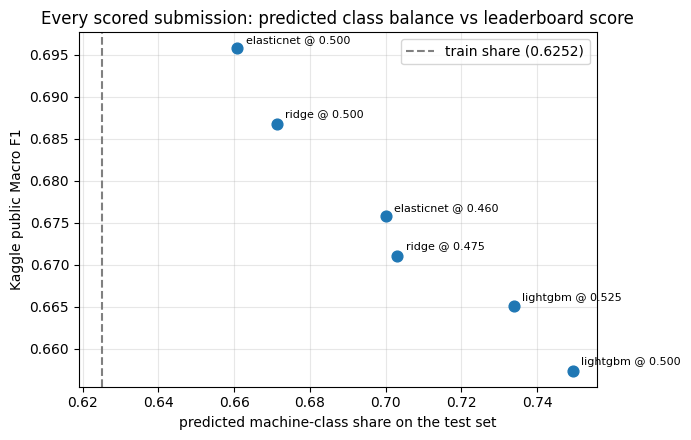

In [4]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(scored["machine_share"], scored["kaggle_f1"], s=60, zorder=3)
for _, r in scored.iterrows():
    ax.annotate(r["submission"], (r["machine_share"], r["kaggle_f1"]),
                textcoords="offset points", xytext=(6, 4), fontsize=8)
ax.axvline(0.6252, color="grey", linestyle="--", label="train share (0.6252)")
ax.set_xlabel("predicted machine-class share on the test set")
ax.set_ylabel("Kaggle public Macro F1")
ax.set_title("Every scored submission: predicted class balance vs leaderboard score")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES / "class_balance_vs_kaggle.png", dpi=120)
plt.show()

## 2. What local validation says about raising the threshold

This section exists to make the trade-off explicit.

The holdout is a split of `train_features.csv`, so it carries the *train* class
distribution. Raising the threshold therefore moves predictions away from what is
optimal on the holdout, and holdout Macro F1 will drop. That is expected and is not a
reason to stop - it is precisely the disagreement between local data and the shifted
test set that this notebook is acting on. But the size of the local sacrifice should be
known, not hidden.

In [5]:
X, y, ids = data.load_train_features()
Xt, test_ids = data.load_test_features()
holdout_idx = np.load(paths.DATA_PROCESSED / "holdout_idx.npy")

dev_fitted = joblib.load(paths.MODELS / "best_logreg_elasticnet_tuned.pkl")  # fit on dev only
hold_proba = dev_fitted.predict_proba(X[holdout_idx])[:, 1]

grid = [0.50, 0.55, 0.60, 0.65]
local = pd.DataFrame([{
    "threshold": t,
    "holdout_f1": evaluation.macro_f1(y[holdout_idx], (hold_proba >= t).astype(int)),
    "holdout_machine_share": (hold_proba >= t).mean(),
} for t in grid])
local["vs_default"] = local["holdout_f1"] - local.loc[0, "holdout_f1"]
print("ElasticNet on the untouched holdout (train distribution):")
print(local.round(4).to_string(index=False))
print(f"\nHoldout true machine share: {y[holdout_idx].mean():.4f}")

ElasticNet on the untouched holdout (train distribution):
 threshold  holdout_f1  holdout_machine_share  vs_default
      0.50      0.7395                 0.5752      0.0000
      0.55      0.7278                 0.5090     -0.0117
      0.60      0.7117                 0.4422     -0.0278
      0.65      0.6857                 0.3860     -0.0538

Holdout true machine share: 0.6252


## 3. Generate the threshold variants

Uses the existing full-refit ElasticNet (fit on all 20,000 labeled rows in 06c) - no
refitting, so these files differ from the already-scored `@ 0.500` submission by the
threshold and nothing else. That is what makes them clean controls.

In [6]:
full = joblib.load(paths.MODELS / "final_logreg_elasticnet_full_refit.pkl")
test_proba = full.predict_proba(Xt)[:, 1]

sample = pd.read_csv(paths.DATA_RAW / "sample_submission.csv", dtype={"id": str})
assert len(test_ids) == 6999, len(test_ids)
assert list(test_ids) == list(sample["id"]), "test ids do not match sample_submission order"

# Bracketing points only. 0.55 and 0.65 span the curve; the midpoint is deliberately
# NOT submitted today so tomorrow's point can be chosen where these two say it matters,
# rather than pre-committed to a grid drawn before any of this was measured.
variants = []
for t in [0.55, 0.65]:
    preds = (test_proba >= t).astype(int)
    fname = f"logreg_elasticnet_thr{int(t * 100)}.csv"
    data.write_submission(test_ids, preds, fname)
    variants.append({"file": fname, "threshold": t,
                     "machine_share": round(float(preds.mean()), 4)})

print(pd.DataFrame(variants).to_string(index=False))

                       file  threshold  machine_share
logreg_elasticnet_thr55.csv       0.55         0.6081
logreg_elasticnet_thr65.csv       0.65         0.4996


In [7]:
# Matched-share ensemble: the 07 ensemble thresholded so its predicted machine share
# EQUALS the best-scoring ElasticNet submission's (0.6608), rather than its natural
# 0.7217 at the default cutoff.
#
# Submitting the ensemble at 0.5 would confound two variables at once - it would differ
# from the ElasticNet benchmark in both model and class balance, so a lower score could
# not be attributed to either. Matching the share holds balance fixed and isolates model
# quality, which is the only thing worth spending a slot to learn about the ensemble.
fitted = joblib.load(paths.MODELS / "final_linear_ensemble_full_refit.pkl")
ens_proba = np.mean([m.predict_proba(Xt)[:, 1] for m in fitted.values()], axis=0)

TARGET_SHARE = 0.6608  # elasticnet @ 0.500, the current best submission
ens_thr = float(np.quantile(ens_proba, 1 - TARGET_SHARE))
ens_preds = (ens_proba >= ens_thr).astype(int)

data.write_submission(test_ids, ens_preds, "linear_ensemble_matched_share.csv")

print(f"Ensemble members: {list(fitted)}")
print(f"Natural share @ 0.500: {(ens_proba >= 0.5).mean():.4f}")
print(f"Matched threshold: {ens_thr:.4f} -> share {ens_preds.mean():.4f} "
      f"(target {TARGET_SHARE})")
print(f"Rows differing from the elasticnet benchmark: "
      f"{(ens_preds != (test_proba >= 0.5).astype(int)).sum()} of {len(ens_preds)}")

Ensemble members: ['logreg_elasticnet', 'linearsvc_cal']
Natural share @ 0.500: 0.7217
Matched threshold: 0.5617 -> share 0.6608 (target 0.6608)
Rows differing from the elasticnet benchmark: 196 of 6999


## 4. Submission batch 



| # | submission | machine share | what it tests |
|---|---|---|---|
| 1 | `linearsvc_task3_default_threshold.csv` | 0.6630 | **Control A.** Almost the same share as the best-scoring ElasticNet (0.6608) but a different model with a different objective, and a *worse* local CV. If it scores near 0.695, share dominates model identity. |
| 2 | `logreg_elasticnet_thr55.csv` | 0.6081 | Lower bracket. The first submission ever to go below train's 62.5% share. |
| 3 | `logreg_elasticnet_thr65.csv` | 0.4996 | Upper bracket, deliberately aggressive. With #2 and the known 0.6608 point this spans the plausible range, so the curve's shape is visible after one day. |
| 4 | `linear_ensemble_matched_share.csv` | 0.6608 | **Control B.** The 07 ensemble, thresholded to *exactly* the benchmark's share. Local CV says it is the best model built (0.7307); holding balance fixed asks whether that survives the shift. |

**Why the midpoint is not submitted today.** A 0.55/0.60/0.65 grid spends three slots
answering a question that two slots can bracket. Holding the midpoint back means
tomorrow's point can be placed where #2 and #3 indicate the peak actually is, which is
worth more than a pre-committed grid line.

**Why the ensemble is share-matched rather than submitted at its default 0.5.** At the
default cutoff it predicts 72.17% machine, a range where every scored submission has
landed between 0.665 and 0.676. Submitting it there would spend a slot on a configuration
that is both predictably poor and uninterpretable, since it would differ from the
benchmark in model *and* balance simultaneously.

**What would falsify the class-balance hypothesis:** if #2 and #3 both score at or below
0.69576, the optimum sits at or above share 0.6608, the monotonic trend was an artifact
of the narrow range sampled so far, and the default threshold stands.

**Reading controls A and B together:**

- Both land near 0.695 -> share is essentially all that matters; pick any decent linear
  model and calibrate its balance.
- B clearly beats 0.69576 while A matches it -> the ensemble is genuinely the better
  model, and the winning final submission is the ensemble set to the optimal share found
  from #2/#3.
- Both fall well short -> model identity matters more than this notebook assumes, and the
  single-model ElasticNet benchmark should be defended rather than replaced.

## 5. Results ledger

Fill in `kaggle_f1` as each score comes back, then re-run this cell to see the curve.

In [8]:
ledger_path = paths.DATA_PROCESSED / "calibration_results.csv"

batch = pd.DataFrame([
    {"file": "linearsvc_task3_default_threshold.csv", "model": "linearsvc",
     "threshold": 0.50, "role": "control A (different model, matched share)"},
    {"file": "logreg_elasticnet_thr55.csv", "model": "logreg_elasticnet",
     "threshold": 0.55, "role": "curve point (lower bracket)"},
    {"file": "logreg_elasticnet_thr65.csv", "model": "logreg_elasticnet",
     "threshold": 0.65, "role": "curve point (upper bracket)"},
    {"file": "linear_ensemble_matched_share.csv", "model": "linear_ensemble",
     "threshold": round(ens_thr, 4), "role": "control B (better model, matched share)"},
])
batch["machine_share"] = [
    round(float(pd.read_csv(paths.SUBMISSIONS / f)["label"].mean()), 4) for f in batch["file"]
]
batch["kaggle_f1"] = np.nan

# Preserve any scores already filled in on a previous run.
if ledger_path.exists():
    prev = pd.read_csv(ledger_path)[["file", "kaggle_f1"]].dropna()
    if len(prev):
        batch = batch.drop(columns="kaggle_f1").merge(prev, on="file", how="left")

batch.to_csv(ledger_path, index=False)
print(batch.to_string(index=False))
print(f"\nBenchmark to beat: elasticnet @ 0.500, share 0.6608, Kaggle 0.69576")
print(f"Ledger: {ledger_path}")

                                 file             model  threshold                                       role  machine_share  kaggle_f1
linearsvc_task3_default_threshold.csv         linearsvc     0.5000 control A (different model, matched share)         0.6630        NaN
          logreg_elasticnet_thr55.csv logreg_elasticnet     0.5500                curve point (lower bracket)         0.6081        NaN
          logreg_elasticnet_thr65.csv logreg_elasticnet     0.6500                curve point (upper bracket)         0.4996        NaN
    linear_ensemble_matched_share.csv   linear_ensemble     0.5617    control B (better model, matched share)         0.6608        NaN

Benchmark to beat: elasticnet @ 0.500, share 0.6608, Kaggle 0.69576
Ledger: C:\Users\Cliffton\Documents\GitHub\2026-50.007-Machine-Learning-GenAI-Content-Detection\data\processed\calibration_results.csv


## Discussion / carry-forward -> Task 4 report

_To be filled in once the four scores come back._

Regardless of outcome, this is the most report-worthy finding of the project: local CV
and holdout ranked LightGBM first, and the leaderboard ranked it last, with predicted
class balance explaining the ordering completely. That is a concrete, measured
illustration of the distribution shift the brief warns about, and it is a better answer
to Task 4's "difficulties faced" question than any tuning table.